In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [80]:
df = pd.read_csv("Travel.csv")
df

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0


In [81]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [82]:
df.isna().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [83]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [84]:
col_with_na = df.columns[df.isna().any()].tolist()
col_with_na

['Age',
 'TypeofContact',
 'DurationOfPitch',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [85]:
df.dtypes


CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64
dtype: object

In [86]:
num_col_na = [
    x for x in col_with_na
    if pd.api.types.is_numeric_dtype(df[x])
]

In [87]:
cat_col = [x for x in df.columns if df[x].dtype=="object"]
cat_col

['TypeofContact',
 'Occupation',
 'Gender',
 'ProductPitched',
 'MaritalStatus',
 'Designation']

In [88]:
num_col = [ x for x in df.columns if x not in cat_col]
num_col

['CustomerID',
 'ProdTaken',
 'Age',
 'CityTier',
 'DurationOfPitch',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [89]:
num_col_na = [
    x for x in col_with_na
    if pd.api.types.is_numeric_dtype(df[x])
]
cat_col_na = [
    x for x in col_with_na
    if pd.api.types.is_object_dtype(df[x])

]
print(num_col_na,"\n",cat_col_na)

['Age', 'DurationOfPitch', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'NumberOfChildrenVisiting', 'MonthlyIncome'] 
 ['TypeofContact']


In [90]:
for x in num_col_na:
    df[x] = df[x].fillna(df[x].mean())


In [91]:
df.isna().sum()

CustomerID                   0
ProdTaken                    0
Age                          0
TypeofContact               25
CityTier                     0
DurationOfPitch              0
Occupation                   0
Gender                       0
NumberOfPersonVisiting       0
NumberOfFollowups            0
ProductPitched               0
PreferredPropertyStar        0
MaritalStatus                0
NumberOfTrips                0
Passport                     0
PitchSatisfactionScore       0
OwnCar                       0
NumberOfChildrenVisiting     0
Designation                  0
MonthlyIncome                0
dtype: int64

In [92]:
for x in cat_col_na:
    df[x] = df[x].fillna(df[x].mode()[0])

In [93]:
df.isna().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [94]:
for x in cat_col:
    print(f"** for {x} values are")
    print(df[x].unique())


** for TypeofContact values are
['Self Enquiry' 'Company Invited']
** for Occupation values are
['Salaried' 'Free Lancer' 'Small Business' 'Large Business']
** for Gender values are
['Female' 'Male' 'Fe Male']
** for ProductPitched values are
['Deluxe' 'Basic' 'Standard' 'Super Deluxe' 'King']
** for MaritalStatus values are
['Single' 'Divorced' 'Married' 'Unmarried']
** for Designation values are
['Manager' 'Executive' 'Senior Manager' 'AVP' 'VP']


In [95]:
df["Gender"] = df["Gender"].replace("Fe Male","Female")

In [96]:
df["Gender"].unique()

array(['Female', 'Male'], dtype=object)

In [97]:
df["MaritalStatus"] = df["MaritalStatus"].replace("Unmarried","Single")
df["MaritalStatus"].unique()

array(['Single', 'Divorced', 'Married'], dtype=object)

<Axes: >

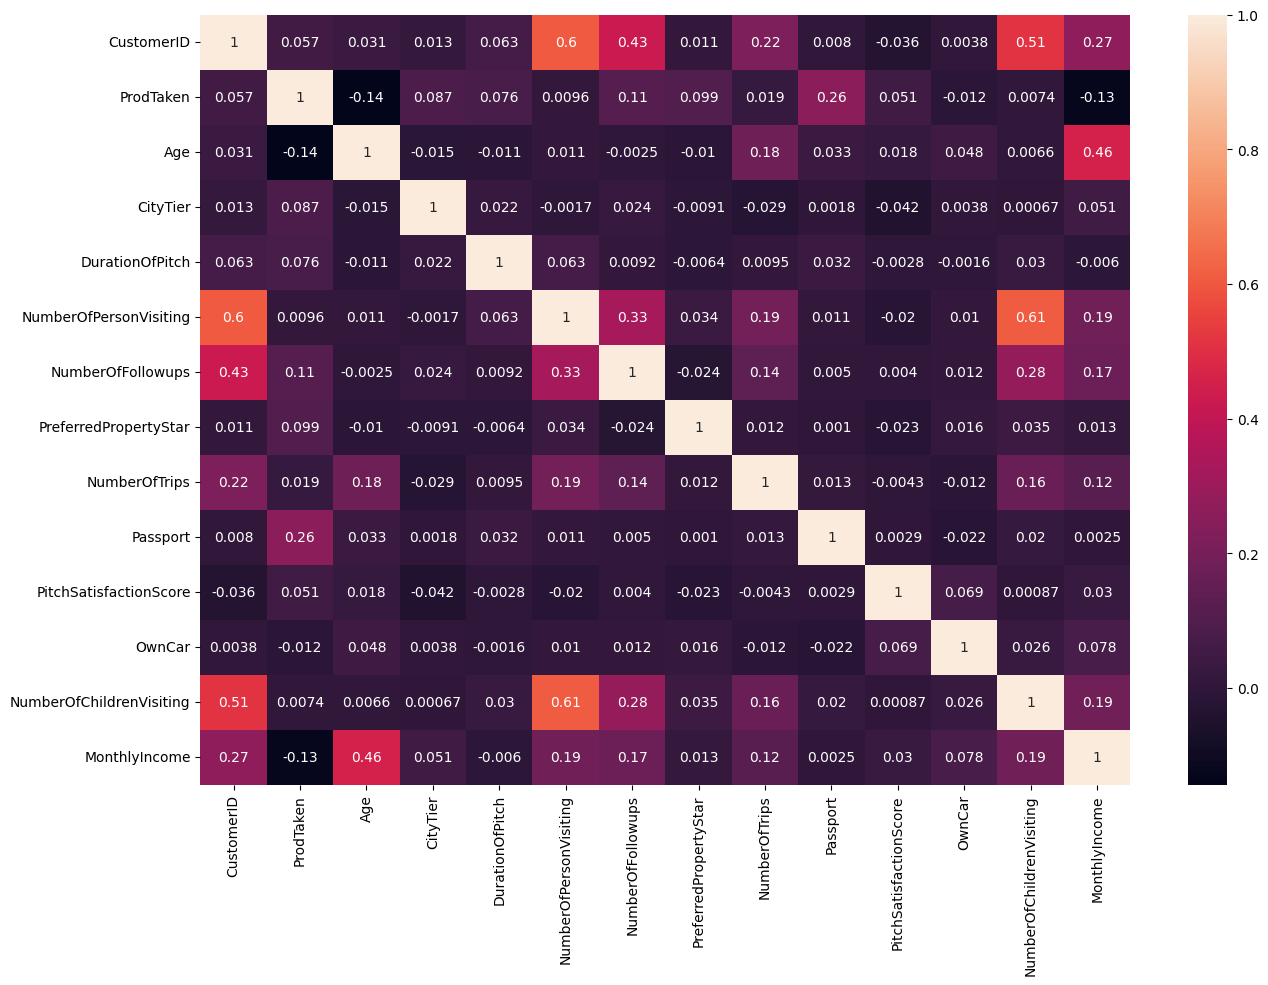

In [98]:
plt.figure(figsize=(15,10))
sns.heatmap(df[num_col].corr(),annot=True)


In [99]:
df.drop('CustomerID',inplace = True,axis=1)

In [100]:
df

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.000000,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.000000,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.000000,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.000000,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,37.622265,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,1,49.000000,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Single,2.0,1,1,1,1.0,Manager,26576.0
4884,1,28.000000,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0
4885,1,52.000000,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,1,19.000000,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0


In [101]:
df["ToatlVisiting"] = df["NumberOfChildrenVisiting"] + df["NumberOfPersonVisiting"]
df.drop(columns=["NumberOfChildrenVisiting","NumberOfPersonVisiting"],inplace=True,axis=1)
df.head(2)

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,ToatlVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(["ProdTaken"],axis=1)
y= df["ProdTaken"]
y.value_counts()


ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [103]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)


In [104]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [113]:
num_col.remove('CustomerID')
num_col.remove("NumberOfPersonVisiting")
num_col.remove("NumberOfChildrenVisiting")
num_col.append("ToatlVisiting")

In [114]:
num_col

['ProdTaken',
 'Age',
 'CityTier',
 'DurationOfPitch',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'MonthlyIncome',
 'ToatlVisiting']

In [118]:
num_col.remove("ProdTaken")

In [119]:
prepocss = ColumnTransformer([("encoder",OneHotEncoder(drop="first"),cat_col),("scaler",StandardScaler(),num_col)])
X_train=prepocss.fit_transform(X_train)
X_test = prepocss.transform(X_test)
X_train

array([[ 1.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.39433315, -0.77594033],
       [ 1.        ,  0.        ,  1.        , ...,  0.78296635,
        -0.47198867,  0.64162114],
       [ 1.        ,  1.        ,  0.        , ...,  0.78296635,
        -0.25710365, -0.06715959],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.37263528,  0.64162114],
       [ 1.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.26471694,  0.64162114],
       [ 0.        ,  0.        ,  1.        , ..., -1.2771941 ,
        -1.09551687, -1.48472106]])

In [125]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
models = {
    "DecisionTreeClassifier":DecisionTreeClassifier(),
    "LogisticRegression":LogisticRegression(),

 "RandomForestClassifier":RandomForestClassifier()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print(f"report for {model} is :")
    print(confusion_matrix(y_test,y_pred))
    print(classification_report(y_test,y_pred))
    print("="*35)

report for DecisionTreeClassifier() is :
[[750  37]
 [ 39 152]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       787
           1       0.80      0.80      0.80       191

    accuracy                           0.92       978
   macro avg       0.88      0.87      0.88       978
weighted avg       0.92      0.92      0.92       978

report for LogisticRegression() is :
[[761  26]
 [135  56]]
              precision    recall  f1-score   support

           0       0.85      0.97      0.90       787
           1       0.68      0.29      0.41       191

    accuracy                           0.84       978
   macro avg       0.77      0.63      0.66       978
weighted avg       0.82      0.84      0.81       978

report for RandomForestClassifier() is :
[[782   5]
 [ 64 127]]
              precision    recall  f1-score   support

           0       0.92      0.99      0.96       787
           1       0.96      0.66      0.79      

In [127]:
rf_params = {
    "max_depth":[5,8,15,None,10],
    "max_features":[5,7,8,"auto"],
    "min_samples_split":[2,8,15,20]
}
## models for hyperparamter tunning
randomCVmodels = [
    ("RF",RandomForestClassifier(),rf_params)
]
    



In [129]:
from sklearn.model_selection import RandomizedSearchCV
randomCVmodels = [
    ("RF",RandomForestClassifier(),rf_params)
]
model_parms = {}
for name,model,params in randomCVmodels:
    random = RandomizedSearchCV(estimator=model,param_distributions=params,n_iter=100,cv=5,n_jobs=-1)
    random.fit(X_train,y_train)
    model_parms[name] = random.best_params_
for model_name in model_parms:
    print(f"----------------------Best params for {model_name} -----------")
    print(model_parms[model_name])

----------------------Best params for RF -----------
{'min_samples_split': 2, 'max_features': 8, 'max_depth': 15}


In [131]:
df = pd.read_csv("cardekho_imputated.csv")
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [132]:
df.isna().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [138]:
df.drop("car_name",inplace=True,axis=1)
df.drop("brand",inplace=True,axis=1)

In [140]:
cat_col = [x for x in df.columns if df[x].dtype == "object"]
num_col = [x for x in df.columns if x not in cat_col]

In [141]:
df.columns

Index(['Unnamed: 0', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(["selling_price"],axis=1)
y= df["selling_price"]



(       Unnamed: 0     model  vehicle_age  km_driven seller_type fuel_type  \
 0               0      Alto            9     120000  Individual    Petrol   
 1               1     Grand            5      20000  Individual    Petrol   
 2               2       i20           11      60000  Individual    Petrol   
 3               3      Alto            9      37000  Individual    Petrol   
 4               4  Ecosport            6      30000      Dealer    Diesel   
 ...           ...       ...          ...        ...         ...       ...   
 15406       19537       i10            9      10723      Dealer    Petrol   
 15407       19540    Ertiga            2      18000      Dealer    Petrol   
 15408       19541     Rapid            6      67000      Dealer    Diesel   
 15409       19542    XUV500            5    3800000      Dealer    Diesel   
 15410       19543      City            2      13000      Dealer    Petrol   
 
       transmission_type  mileage  engine  max_power  seats  


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)

In [148]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
le = LabelEncoder()
X["model"] = le.fit_transform(X["model"])


In [157]:
X

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,7,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,54,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,118,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,7,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,38,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5
...,...,...,...,...,...,...,...,...,...,...
15406,117,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5
15407,42,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7
15408,77,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5
15409,114,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7


In [156]:
df.drop("Unnamed: 0",inplace=True,axis=1)

In [161]:
cat_col = [x for x in df.columns if df[x].dtype == "object"]
num_col = [x for x in df.columns if x not in cat_col]
cat_col.remove('model')

In [164]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
prepocss = ColumnTransformer([("scaler",StandardScaler(),num_col),("onehotencoder",OneHotEncoder(drop="first"),cat_col)],remainder="passthrough")


In [ ]:
X_train = prepocss.fit_transform()